# Point-cloud segmentation via image-match classification

Showcase of the **`substrata.segmentation`** module: segment a point cloud by reusing the trained
crop classifier — sample query points across the cloud, project each to its best camera photo,
classify the 224 px patch, then propagate the labels to every point and recolour (category tint ×
original luminance).

This notebook drives the production API — `segment_point_cloud()`, the `Segmentation` class, and
the streaming `recolor_ply_file()`. The exact same workflow is available on the command line as
`substrata segment` (see the last cell).

Query matching is fully vectorized and occlusion-aware, so cost scales with the number of query
points (the spacing), not the number of cloud points.


In [1]:
import os
import time

import numpy as np

from substrata import segmentation, classification, pointclouds, visualizations
from substrata.initializer import ProjectInitializer

# ---- Config -----------------------------------------------------------------
PROJECT_DIR = "/mnt/sdd/curacao_focal/cur_sna_20m_20200303"          # <-- EDIT

# Force a specific classifier (else uses the project YAML's 'classifier').
CLASSIFIER = (
    "/home/pimbongaerts/Github/substrata/sandbox/caribbean_simplified.pkl"
)

# Camera poses may reference a mount that differs from where the photos live
# locally — remap it (substring find -> replace), or set to None if not needed.
PHOTO_PATH_REPLACE = (
    "/home/deepcat/mounts/coral3d/focal_plots/cur_sna/cur_sna_20m/",
    "/mnt/sdd/curacao_focal/",
)

# Manual category colours (0-255). Keys must match the classifier's labels;
# this Caribbean model uses CS/CCA/MA/TURF/SP/S.
LABEL_COLORS = {
    "CS": (120, 170, 230),   # coral -> (hex: #78AAE6)
    "CCA": (225, 135, 190),  # CCA ->   (hex: #E187BE)
    "MA": (130, 170, 110),   # macroalgae ->   (hex: #82AA6E)
    "TURF": (200, 220, 140), # turf algae ->   (hex: #C8DC8C)
    "SP": (240, 170, 105),   # sponges ->   (hex: #F0AA69)
    "S": (220, 195, 125),    # sand ->   (hex: #DCC37D)
}

# query spacing / voxel size in metres. The useful floor is ~ the crop footprint
# (printed as "[footprint]" right after matching); sampling much finer than that
# just re-classifies heavily overlapping patches. For this rig the footprint is
# ~3.5 cm, so 0.025 m is near the sweet spot. Memory is bounded now, so smaller
# cell sizes are safe (only slower) — 0.025 / 0.01 no longer OOM.
CELL_SIZE   = 0.025
SAMPLING    = "voxel"   # "voxel" (3D, gap-free) or "xy_grid" (top-down)
OCCLUSION   = True      # reprojection occlusion filtering
MAX_RADIUS  = None      # propagation cap in m (None = label every point)

# Fast test mode: cap the query points for a quick end-to-end pass while
# iterating. Set to None to run the full grid via segment_point_cloud().
MAX_QUERIES = None


## 1. Load the project + classifier

In [2]:
init = ProjectInitializer(path=PROJECT_DIR)
init.reset_paths_to_local(PROJECT_DIR)
init.initialize()
if PHOTO_PATH_REPLACE:
    init.cams.set_filepath_replace(*PHOTO_PATH_REPLACE)

pcd, cams = init.pcd, init.cams
print(f"cloud: {len(np.asarray(pcd.points)):,} points, {len(list(cams))} cameras")

learn = classification.get_image_classifier(CLASSIFIER or init.classifier_filepath)
print("classifier device:", classification._learner_device(learn))


Loading project from YAML file: /mnt/sdd/curacao_focal/cur_sna_20m_20200303/cur_sna_20m_20200303.yaml
Loading pointcloud from /mnt/sdd/curacao_focal/cur_sna_20m_20200303/cur_sna_20m_20200303_dec50M.ply
Loading cameras from /mnt/sdd/curacao_focal/cur_sna_20m_20200303/cur_sna_20m_20200303.meta.json and /mnt/sdd/curacao_focal/cur_sna_20m_20200303/cur_sna_20m_20200303.cams.xml
Loading markers from /mnt/sdd/curacao_focal/cur_sna_20m_20200303/cur_sna_20m_20200303_markers.csv
Applying world_transform to loaded objects:
[[ 3.22928062e-02 -1.28891699e-01  5.02014825e-02  9.95712208e+00]
 [ 1.10971676e-01 -6.63363845e-03 -8.84158702e-02  2.60615978e+00]
 [ 8.25744872e-02  5.93212358e-02  9.91893604e-02 -1.93335913e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
cloud: 50,000,000 points, 940 cameras
classifier device: cuda


/home/pimbongaerts/miniconda3/envs/substrata/lib/python3.10/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


## 2. Segment the cloud

The full grid is a single call to `segment_point_cloud()`. In fast test mode we subsample the query
grid and drive the same pipeline through the module internals (`sample_query_points` →
`_match_points_to_cameras` → `_classify_crops`) so a full end-to-end pass takes seconds.

In [3]:
t = time.time()
if MAX_QUERIES:
    # Fast test mode: subsample the query grid, then use the module internals.
    qc = segmentation.sample_query_points(pcd, CELL_SIZE, method=SAMPLING)
    rng = np.random.default_rng(0)
    qc = qc[rng.choice(len(qc), min(MAX_QUERIES, len(qc)), replace=False)]
    bc, bx, by, bd, cam_list = segmentation._match_points_to_cameras(
        qc, cams, world_transform=pcd.world_transform,
        pcd=(pcd if OCCLUSION else None), occlusion=OCCLUSION,
    )
    labels, conf = segmentation._classify_crops(qc, bc, bx, by, cam_list, learn)
    seg = segmentation.Segmentation.from_query_labels(
        qc, labels, conf, label_colors=LABEL_COLORS)
else:
    # Production one-liner: sample -> match -> classify -> Segmentation.
    seg = segmentation.segment_point_cloud(
        pcd, cams, learn,
        world_transform=pcd.world_transform,
        cell_size=CELL_SIZE, sampling=SAMPLING,
        occlusion=OCCLUSION,
        label_colors=LABEL_COLORS,
    )

print(f"\n{seg.n_queries:,} classified query points in {time.time() - t:.1f}s")
print("codebook:", seg.codebook, "| colors:", seg.label_colors)


[sample] 941,736 query points (voxel, 2 cm)


Occlusion check: 100%|███████████████████████████████████████████████████████████| 941736/941736 [13:45<00:00, 1141.22pt/s]


[match] 874,918/941,736 queries matched
[footprint] crop ~= 4.7 cm on substrate (5-95 pct 3.4-6.5 cm; crop 224px, fx 6337px, depth 1.34 m)
  940 unique photos; example: /mnt/sdd/curacao_focal/cur_sna_20m_20200303/cur_sna_20m_20200303.photos/0X7A5931.jpg (exists=True)


Decoding photos: 100%|████████████████████████████████████████████████████████████████| 940/940 [16:35<00:00,  1.06s/photo]


  classified 874918 crops (0 dropped as out-of-bounds)
[classify] 874,918 classified

874,918 classified query points in 1915.3s
codebook: ['CCA', 'CS', 'MA', 'S', 'SP', 'TURF'] | colors: {'CCA': (225, 135, 190), 'CS': (120, 170, 230), 'MA': (130, 170, 110), 'S': (220, 195, 125), 'SP': (240, 170, 105), 'TURF': (200, 220, 140)}


## 3. Propagate labels to every point + category breakdown

In [4]:
pts = np.asarray(pcd.points)
codes = seg.propagate(pts, max_radius=MAX_RADIUS)   # int16 per-point label codes (-1 = none)
print(f"labeled {int((codes >= 0).sum()):,}/{len(codes):,} points\n")
for lbl, cnt in sorted(seg.summary(codes).items(), key=lambda kv: -kv[1]):
    print(f"  {lbl}: {cnt:,} ({100 * cnt / len(codes):.1f}%)")


labeled 50,000,000/50,000,000 points

  TURF: 23,582,289 (47.2%)
  CS: 7,347,812 (14.7%)
  MA: 7,224,496 (14.4%)
  S: 7,186,987 (14.4%)
  SP: 4,424,506 (8.8%)
  CCA: 233,910 (0.5%)


## 4. Visualize on the decimated cloud

`Segmentation.recolor` blends each point's category colour with its own luminance (relief stays
visible). Displayed via the existing `visualizations.plot_2d` / `show`.

Rasterizing (3434x582 px): 100%|█████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 57.52it/s]


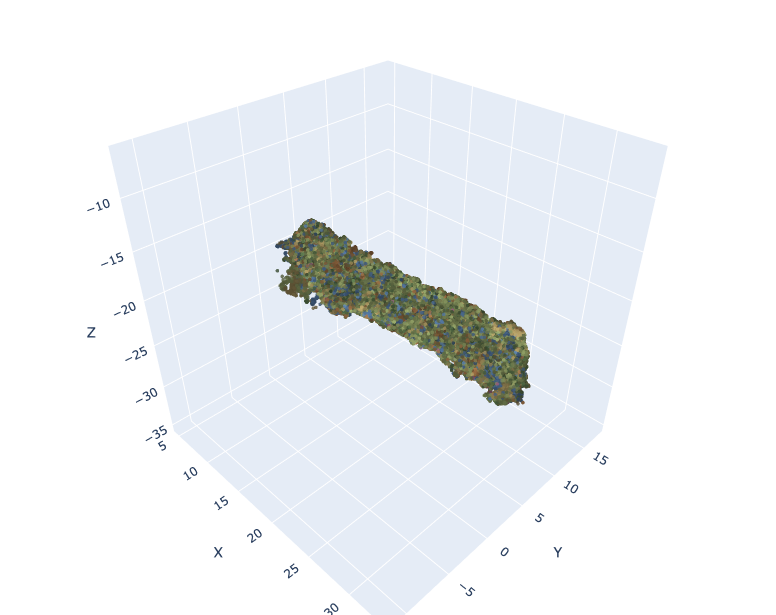

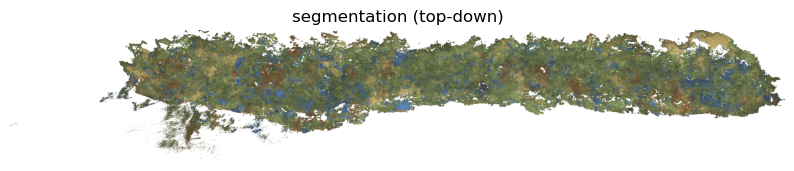

In [5]:
new_colors = seg.recolor(np.asarray(pcd.colors), codes)   # category tint x luminance (0-1 RGB)

# SimplePointCloud expects normals; supply the cloud's (or zeros if the PLY has none).
normals = np.asarray(pcd.normals)
if normals.shape != pts.shape:
    normals = np.zeros_like(pts)
seg_pcd = pointclouds.SimplePointCloud(points=pts, colors=new_colors, normals=normals)

visualizations.plot_2d(seg_pcd, title="segmentation (top-down)")
visualizations.show(seg_pcd, max_output_points=400_000)


## 5. Persist (npz) + reload, and optionally recolour the full-size PLY

The `.npz` stores only the classified query points (the tiny source of truth). The full-size PLY is
recoloured by streaming (`recolor_ply_file`) — memory-safe, never loaded whole.

In [6]:
seg_path = os.path.join(PROJECT_DIR, f"{init.id}_seg.npz")
seg.save(seg_path)
print(f"saved {seg_path} "
      f"({os.path.getsize(seg_path) / 1e3:.0f} kB, {seg.n_queries:,} query points)")

seg2 = segmentation.Segmentation.load(seg_path)
print("reload identical:",
      np.array_equal(codes, seg2.propagate(pts, max_radius=MAX_RADIUS)))

# Stream-recolour the FULL-size PLY (memory-safe). Can be large/slow — set to True to run.
RECOLOR_FULL_PLY = True
if RECOLOR_FULL_PLY:
    out_ply = os.path.join(PROJECT_DIR, f"{init.id}_seg.ply")
    segmentation.recolor_ply_file(
        os.path.join(PROJECT_DIR, f"{init.id}.ply"), out_ply, seg,
        world_transform=pcd.world_transform, max_radius=MAX_RADIUS,
    )
    print("wrote", out_ply)

saved /mnt/sdd/curacao_focal/cur_sna_20m_20200303/cur_sna_20m_20200303_seg.npz (13007 kB, 874,918 query points)
reload identical: True


Recolouring PLY: 100%|████████████████████████████████████████████████| 2418370409/2418370409 [10:12<00:00, 3948969.89pt/s]

wrote /mnt/sdd/curacao_focal/cur_sna_20m_20200303/cur_sna_20m_20200303_seg.ply


## Same thing from the command line

The whole workflow above is also a CLI verb — run from inside the project directory:

```bash
# npz + recoloured decimated cloud (auto-detects project + classifier from CWD)
substrata segment --local \
    --classifier /path/to/crop_classifier.pkl \
    --color CS=78aae6 --color MA=82aa6e --color S=dcc37d \
    --photo-path-replace /home/deepcat/mounts/coral3d/focal_plots/cur_sna/cur_sna_20m/ \
                         /mnt/sdd/curacao_focal/

# also stream-recolour the full-size PLY -> <id>_seg.ply
substrata segment --local --full-ply ...
```

Options: `--cell-size`, `--sampling voxel|xy_grid`, `--no-occlusion`, `--max-radius`,
`--output-npz`, `--output-ply`. See `substrata segment --help`.

---

This is now shipped in `substrata.segmentation` (`segment_point_cloud`, `Segmentation`,
`sample_query_points`, `recolor_ply_file`) and as `substrata segment`. Matching is vectorized
(`Camera.project_points`) and occlusion-aware; the `.npz` holds only the classified query points, so
per-point labels cost nothing on disk until you `propagate`.

Ideas to explore next: confidence thresholding (drop low-confidence queries before propagation),
`xy_grid` vs `voxel` per site, and tuning the recolour `value_floor`.